In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation_final.csv')

In [39]:
df.shape

(3552, 18)

In [40]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sbtl caladium,sector 109,1.30,6915.0,3.0,2.0,3,16.0,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,134.0
1,flat,bestech park view sanskruti,sector 92,1.83,7871.0,4.0,3.0,3,8.0,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,128.0
2,flat,gls arawali homes,sohna road,0.28,5983.0,2.0,2.0,2,3.0,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0
3,flat,ats triumph,sector 104,2.60,8254.0,4.0,4.0,3+,12.0,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,118.0
4,house,independent,sector 12,0.70,4118.0,4.0,4.0,1,2.0,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [41]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [42]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 109,1.30,3.0,2.0,3,16.0,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,134.0
1,flat,sector 92,1.83,4.0,3.0,3,8.0,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,128.0
2,flat,sohna road,0.28,2.0,2.0,2,3.0,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0
3,flat,sector 104,2.60,4.0,4.0,3+,12.0,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,118.0
4,house,sector 12,0.70,4.0,4.0,1,2.0,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### luxury score

<Axes: ylabel='luxury_score'>

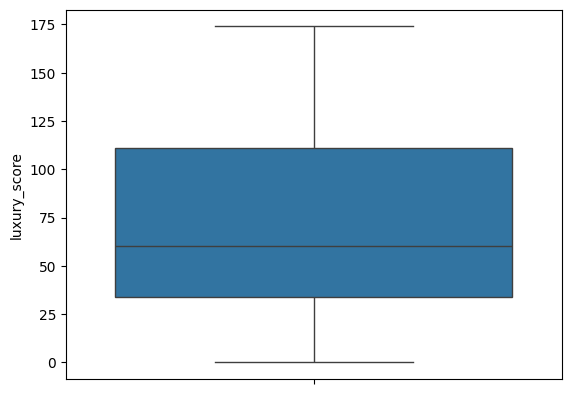

In [43]:
sns.boxplot(df['luxury_score'])

In [44]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [45]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [46]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 109,1.30,3.0,2.0,3,16.0,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,134.0,Medium
1,flat,sector 92,1.83,4.0,3.0,3,8.0,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,128.0,Medium
2,flat,sohna road,0.28,2.0,2.0,2,3.0,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,Low
3,flat,sector 104,2.60,4.0,4.0,3+,12.0,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,118.0,Medium
4,house,sector 12,0.70,4.0,4.0,1,2.0,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low


### floorNum

<Axes: ylabel='floorNum'>

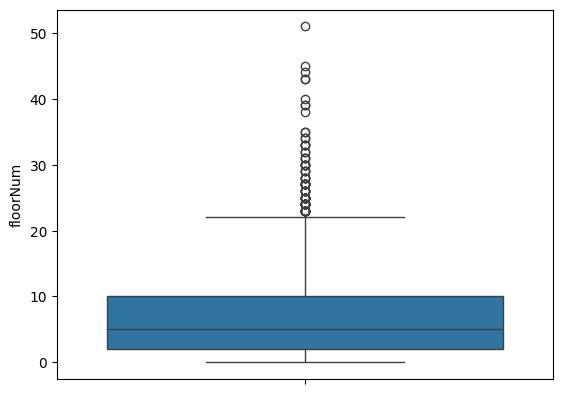

In [47]:
sns.boxplot(df['floorNum'])

In [48]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [49]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [50]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 109,1.30,3.0,2.0,3,16.0,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,134.0,Medium,High Floor
1,flat,sector 92,1.83,4.0,3.0,3,8.0,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,128.0,Medium,Mid Floor
2,flat,sohna road,0.28,2.0,2.0,2,3.0,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,Low,Mid Floor
3,flat,sector 104,2.60,4.0,4.0,3+,12.0,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,118.0,Medium,High Floor
4,house,sector 12,0.70,4.0,4.0,1,2.0,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low,Low Floor


In [51]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [52]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 109,1.30,3.0,2.0,3,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,Medium,High Floor
1,flat,sector 92,1.83,4.0,3.0,3,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,Medium,Mid Floor
2,flat,sohna road,0.28,2.0,2.0,2,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,Mid Floor
3,flat,sector 104,2.60,4.0,4.0,3+,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,Medium,High Floor
4,house,sector 12,0.70,4.0,4.0,1,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,Low Floor


In [53]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

C:\Users\Aadi\AppData\Local\Temp\ipykernel_20308\848989002.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns


In [54]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,13.0,3.0,2.0,3.0,0.0,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
1,0.0,107.0,4.0,3.0,3.0,1.0,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0
2,0.0,113.0,2.0,2.0,2.0,3.0,520.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3,0.0,8.0,4.0,4.0,4.0,3.0,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0.0
4,1.0,20.0,4.0,4.0,1.0,0.0,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3547,0.0,45.0,2.0,3.0,4.0,3.0,1300.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
3548,0.0,7.0,2.0,2.0,3.0,0.0,1288.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3549,0.0,111.0,2.0,2.0,2.0,1.0,473.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
3550,0.0,97.0,2.0,2.0,3.0,3.0,1300.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


In [55]:
y_label

0       1.30
1       1.83
2       0.28
3       2.60
4       0.70
        ... 
3547    0.87
3548    1.20
3549    0.32
3550    0.95
3551    7.40
Name: price, Length: 3552, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

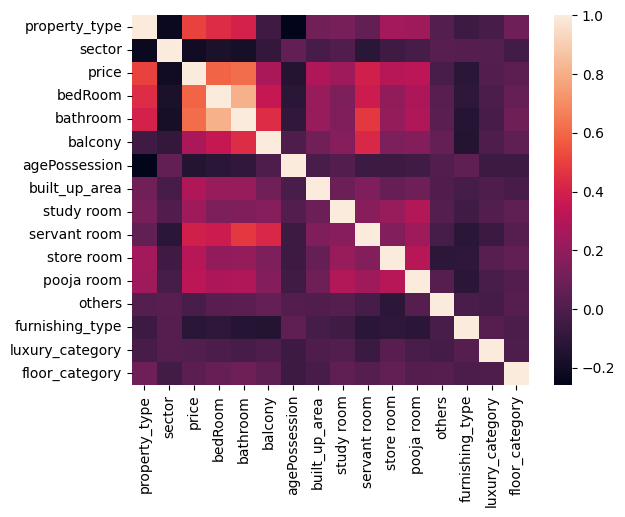

In [56]:
sns.heatmap(data_label_encoded.corr())

In [57]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.203827
1,price,1.000000
2,bedRoom,0.589772
3,bathroom,0.612174
4,balcony,0.271193
5,agePossession,-0.140398
6,built_up_area,0.289826
7,study room,0.240124
8,servant room,0.393038
9,store room,0.310260


### Technique 2 - Random Forest Feature Importance

In [58]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.628897
0,property_type,0.110329
1,sector,0.109868
2,bedRoom,0.030033
3,bathroom,0.026964
8,servant room,0.021426
5,agePossession,0.015474
4,balcony,0.012297
13,luxury_category,0.008256
12,furnishing_type,0.008180


### Technique 3 - Gradient Boosting Feature importances

In [59]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.668806
1,sector,0.103962
0,property_type,0.101862
2,bedRoom,0.039978
3,bathroom,0.037503
8,servant room,0.027342
9,store room,0.007912
5,agePossession,0.005867
12,furnishing_type,0.002417
7,study room,0.001211


### Technique 4 - Permutation Importance

In [60]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.659093
1,sector,0.186846
0,property_type,0.165763
8,servant room,0.031987
2,bedRoom,0.017785
3,bathroom,0.011406
9,store room,0.006408
4,balcony,0.002873
10,pooja room,0.000980
14,floor_category,0.000614


### Technique 5 - LASSO

In [61]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
0,property_type,0.766338
3,bathroom,0.619234
2,bedRoom,0.411305
8,servant room,0.391397
6,built_up_area,0.371518
9,store room,0.252872
7,study room,0.221761
10,pooja room,0.127171
13,luxury_category,0.070283
4,balcony,0.060298


### Technique 6 - RFE

In [62]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,built_up_area,0.625906
0,property_type,0.115261
1,sector,0.107600
3,bathroom,0.028010
2,bedRoom,0.026419
8,servant room,0.022740
5,agePossession,0.014939
4,balcony,0.012176
12,furnishing_type,0.009855
13,luxury_category,0.007420


### Technique 7 - Linear Regression Weights

In [63]:
from sklearn.linear_model import LinearRegression

# Train model
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
0,property_type,0.771824
3,bathroom,0.616850
2,bedRoom,0.411752
8,servant room,0.394359
6,built_up_area,0.378560
9,store room,0.255422
7,study room,0.228183
10,pooja room,0.130430
13,luxury_category,0.080080
4,balcony,0.067070


### Technique 8 - SHAP

In [64]:
!pip install shap


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[-2.61851448e-01, -1.34560669e-01,  6.07600425e-04, ...,
        -1.39354747e-02,  2.74671928e-03,  4.53894317e-02],
       [-4.16973255e-01, -7.69003980e-01,  1.72348419e-02, ...,
        -2.78314574e-02, -2.49762528e-03,  8.96670783e-04],
       [-2.00546839e-01, -4.35826186e-01, -4.90843523e-02, ...,
        -9.87665559e-03, -3.85817365e-03, -6.98951194e-03],
       ...,
       [-2.00377145e-01, -4.37451302e-01, -4.86585847e-02, ...,
        -1.02095737e-02,  2.43048984e-03, -3.30876340e-03],
       [-2.09157501e-01, -3.57764722e-01, -7.18590094e-02, ...,
         1.16377571e-03, -6.91023556e-03, -7.72615799e-03],
       [-1.69861831e-01,  1.16857982e+00,  1.36126721e-01, ...,
        -1.27935954e-02,  2.79874337e-02,  2.75223503e-01]],
      shape=(3552, 15))

In [65]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.234518
0,property_type,0.486313
1,sector,0.401433
3,bathroom,0.114746
8,servant room,0.097068
2,bedRoom,0.068519
4,balcony,0.041085
5,agePossession,0.029301
12,furnishing_type,0.025863
14,floor_category,0.024786


In [66]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [67]:
final_fi_df


,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.203827,0.109868,0.103962,0.186846,-0.131610,0.107600,-0.139225,0.401433
bedRoom,0.589772,0.030033,0.039978,0.017785,0.411305,0.026419,0.411752,0.068519
bathroom,0.612174,0.026964,0.037503,0.011406,0.619234,0.028010,0.616850,0.114746
balcony,0.271193,0.012297,0.001089,0.002873,0.060298,0.012176,0.067070,0.041085
agePossession,-0.140398,0.015474,0.005867,-0.004615,-0.023910,0.014939,-0.031261,0.029301
built_up_area,0.289826,0.628897,0.668806,0.659093,0.371518,0.625906,0.378560,1.234518
study room,0.240124,0.006301,0.001211,-0.023962,0.221761,0.005665,0.228183,0.019070
servant room,0.393038,0.021426,0.027342,0.031987,0.391397,0.022740,0.394359,0.097068
store room,0.310260,0.006378,0.007912,0.006408,0.252872,0.006871,0.255422,0.013215


In [68]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [69]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.699620
sector             0.152985
bathroom           0.034248
servant room       0.032572
bedRoom            0.032197
balcony            0.010318
agePossession      0.009891
store room         0.007468
floor_category     0.005348
furnishing_type    0.004732
luxury_category    0.004592
pooja room         0.004295
others             0.002431
study room        -0.000696
dtype: float64

In [70]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,13.0,3.0,2.0,3.0,0.0,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
1,0.0,107.0,4.0,3.0,3.0,1.0,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0
2,0.0,113.0,2.0,2.0,2.0,3.0,520.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3,0.0,8.0,4.0,4.0,4.0,3.0,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0.0
4,1.0,20.0,4.0,4.0,1.0,0.0,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3547,0.0,45.0,2.0,3.0,4.0,3.0,1300.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
3548,0.0,7.0,2.0,2.0,3.0,0.0,1288.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3549,0.0,111.0,2.0,2.0,2.0,1.0,473.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
3550,0.0,97.0,2.0,2.0,3.0,3.0,1300.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


In [71]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [72]:
scores.mean()

np.float64(0.7907429069758044)

In [73]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [74]:
scores.mean()

np.float64(0.7812213803916519)

In [75]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [ ]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [77]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,13.0,3.0,2.0,3.0,0.0,1701.0,0.0,0.0,1.0,2.0,0.0,1.30
1,0.0,107.0,4.0,3.0,3.0,1.0,2104.0,1.0,0.0,1.0,2.0,2.0,1.83
2,0.0,113.0,2.0,2.0,2.0,3.0,520.0,0.0,0.0,1.0,1.0,2.0,0.28
3,0.0,8.0,4.0,4.0,4.0,3.0,2851.0,1.0,0.0,1.0,2.0,0.0,2.60
4,1.0,20.0,4.0,4.0,1.0,0.0,1700.0,0.0,0.0,1.0,1.0,1.0,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3547,0.0,45.0,2.0,3.0,4.0,3.0,1300.0,0.0,0.0,1.0,2.0,2.0,0.87
3548,0.0,7.0,2.0,2.0,3.0,0.0,1288.0,0.0,0.0,1.0,1.0,2.0,1.20
3549,0.0,111.0,2.0,2.0,2.0,1.0,473.0,0.0,0.0,1.0,2.0,1.0,0.32
3550,0.0,97.0,2.0,2.0,3.0,3.0,1300.0,0.0,0.0,0.0,2.0,2.0,0.95
